# Market-Making Microstructure Lab

*A simulation study of inventory risk, adverse selection, and quote execution.*

---

**What this is.** This project began as a set of market-making and betting-game
exercises (the Deep-ML "Market-Making & Betting-Game Simulator"). I've refactored
the quoting logic into a clean, class-based simulation engine and added the one
ingredient the original exercises left out: **order flow that actually responds to
your quotes.** With that in place, quoting decisions have consequences, and we can
ask a real question:

> Given inventory risk, toxic (informed) flow, and spread-dependent fills, *which
> quoting policy actually survives — and under which market conditions?*

**What this is *not*.** It is not a production trading system, and it does not claim
one quoting rule is universally "best." The interesting result below is a nuanced
one: a well-tuned linear inventory skew is very competitive in calm markets, while
the Avellaneda–Stoikov policy earns its keep specifically in hostile regimes. Every
number and chart in this notebook is produced by the code you can run here.

## 1. The three risks a market maker faces

A market maker quotes a **bid** (price to buy) and an **ask** (price to sell)
simultaneously, hoping to earn the spread as counterparties trade against both
sides. Three forces work against that:

1. **Inventory risk.** Fills are random, so you accumulate a net long or short
   position. While you hold it, the mid-price moves, and unhedged inventory is a
   directional bet you never wanted.
2. **Adverse selection.** Some counterparties know something you don't. *Informed*
   flow trades with you only when it is profitable for **them** — i.e. precisely
   when it is a loss for you. The more toxic the flow, the more your "spread
   capture" is really just paying informed traders.
3. **Execution risk.** Quote too wide and you rarely get filled; quote too tight
   and you get filled constantly at thin (or negative) edge. The fill rate is a
   decreasing function of how far your quote sits from fair value.

A serious simulation has to model all three. The original exercise modelled the
first two but fed the strategy an *exogenous* order sequence — the fills didn't
depend on where you quoted, so execution risk was absent and quoting choices were
inert. Fixing that is the core of this lab.

## 2. The market model

**Reference price.** The mid follows a random walk over $T$ discrete steps,
$m_{t+1} = m_t + \sigma\,\varepsilon_t,\ \varepsilon_t\sim\mathcal N(0,1)$, starting
at $m_0 = S_0$. Leftover inventory is settled at the terminal value $V = m_T$, so
carrying inventory while the mid drifts is genuine P&L risk.

**Execution (the missing piece).** Uninformed "noise" traders arrive on a random
side. A quote posted a distance $\delta$ from the mid is filled with probability

$$P(\text{fill}\mid\delta) = \min\!\big(1,\; e^{-k\,\delta}\big),$$

the Avellaneda–Stoikov Poisson-intensity form: fills decay exponentially as you
widen. This is what turns quoting into a real risk–reward trade-off.

**Adverse selection.** A fraction $\phi$ of arrivals are *informed*: they know the
settlement $V$ and trade only when it profits them — lifting our ask when
$\text{ask} < V$, hitting our bid when $\text{bid} > V$. They only ever trade when
it hurts us, which is exactly what toxic flow means.

## 3. Avellaneda–Stoikov quoting

The classic policy has **two** coupled parts — implementing only the first (as is
common) reduces it to dressed-up linear skew.

**Reservation price** — your private valuation given inventory $q$, risk aversion
$\gamma$, volatility $\sigma$, and time remaining $(T-t)$:

$$r(m, q, t) = m - q\,\gamma\,\sigma^{2}\,(T-t).$$

**Optimal spread** — how wide to quote around that reservation price:

$$\delta_{\text{bid}} + \delta_{\text{ask}}
= \gamma\,\sigma^{2}\,(T-t) + \frac{2}{\gamma}\ln\!\Big(1 + \frac{\gamma}{k}\Big).$$

An honest note on intuition: because both the skew and the spread scale with
$(T-t)$, the policy is *most* cautious early, when a long risk horizon remains, and
*relaxes* its inventory penalty as settlement approaches and there's little time left
for the mid to move against a residual position. (This is the opposite of the common
"panic-dump at the close" story — worth stating plainly rather than repeating the
myth.)

In [1]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Callable, Dict, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# --- primitives carried over from the original exercise ---
def expected_value(values, probabilities) -> float:
    return float(np.dot(np.asarray(values, float), np.asarray(probabilities, float)))

def mark_to_market_pnl(cash: float, inventory: float, settlement: float) -> float:
    return float(cash + inventory * settlement)

def summarize_pnls(pnls) -> Dict[str, float]:
    a = np.asarray(pnls, float)
    return {"mean": float(a.mean()), "std": float(a.std(ddof=0)),
            "worst": float(a.min()),
            "ret_over_risk": float(a.mean() / (a.std(ddof=0) + 1e-12))}

@dataclass
class MarketConfig:
    S0: float = 100.0          # starting mid
    sigma: float = 0.30        # per-step std of the mid random walk
    T: int = 100               # steps per episode
    gamma: float = 0.10        # A-S risk aversion
    k: float = 1.50            # fill-intensity decay
    toxic_frac: float = 0.15   # fraction of arrivals that are informed
    base_half_spread: float = 0.90   # half-spread for naive / linear
    skew_strength: float = 0.30      # inventory skew for the linear policy

print("Config and primitives ready.")

Config and primitives ready.


In [2]:
# Each strategy maps (mid, inventory q, step t, cfg) -> (bid, ask)

def quote_naive(mid, q, t, cfg):
    h = cfg.base_half_spread
    return mid - h, mid + h

def quote_linear_skew(mid, q, t, cfg):
    center = mid - cfg.skew_strength * q          # shift against inventory
    h = cfg.base_half_spread
    return center - h, center + h

def quote_avellaneda_stoikov(mid, q, t, cfg):
    tau      = cfg.T - t                           # steps of variance remaining
    var_rem  = cfg.sigma ** 2 * tau
    reserve  = mid - q * cfg.gamma * var_rem        # reservation price
    spread   = cfg.gamma * var_rem + (2.0 / cfg.gamma) * np.log1p(cfg.gamma / cfg.k)
    half     = spread / 2.0
    return reserve - half, reserve + half

STRATEGIES: Dict[str, Callable] = {
    "Naive symmetric":       quote_naive,
    "Linear inventory skew": quote_linear_skew,
    "Avellaneda-Stoikov":    quote_avellaneda_stoikov,
}
print("Strategies:", list(STRATEGIES))

Strategies: ['Naive symmetric', 'Linear inventory skew', 'Avellaneda-Stoikov']


In [3]:
@dataclass
class EpisodeResult:
    pnl: float
    terminal_inventory: float
    max_abs_inventory: float
    n_fills: int
    n_toxic_fills: int
    adverse_cost: float
    inventory_path: np.ndarray = field(repr=False, default=None)

def simulate_episode(strategy, cfg, rng, keep_path=False) -> EpisodeResult:
    # Pre-generate the whole mid path so informed traders can "know" terminal V.
    shocks = rng.normal(0.0, cfg.sigma, size=cfg.T)
    mid = cfg.S0 + np.concatenate([[0.0], np.cumsum(shocks)])   # len T+1
    V = float(mid[cfg.T])

    cash, q = 0.0, 0.0
    n_fills = n_toxic = 0
    adverse_cost = 0.0
    inv_path = np.empty(cfg.T) if keep_path else None

    for t in range(cfg.T):
        m = float(mid[t])
        bid, ask = strategy(m, q, t, cfg)

        if rng.random() < cfg.toxic_frac:                 # informed / toxic
            if ask < V:                                    # they buy, we sell too cheap
                cash += ask; q -= 1.0; n_fills += 1; n_toxic += 1
                adverse_cost += (V - ask)
            elif bid > V:                                  # they sell, we buy too dear
                cash -= bid; q += 1.0; n_fills += 1; n_toxic += 1
                adverse_cost += (bid - V)
        else:                                              # uninformed / noise
            if rng.random() < 0.5:                         # incoming buy -> our ask
                if rng.random() < min(1.0, np.exp(-cfg.k * (ask - m))):
                    cash += ask; q -= 1.0; n_fills += 1
            else:                                          # incoming sell -> our bid
                if rng.random() < min(1.0, np.exp(-cfg.k * (m - bid))):
                    cash -= bid; q += 1.0; n_fills += 1

        if keep_path:
            inv_path[t] = q

    return EpisodeResult(
        pnl=mark_to_market_pnl(cash, q, V),
        terminal_inventory=q,
        max_abs_inventory=float(np.max(np.abs(inv_path))) if keep_path else abs(q),
        n_fills=n_fills, n_toxic_fills=n_toxic,
        adverse_cost=adverse_cost, inventory_path=inv_path,
    )

def run_stress_test(cfg, n_episodes, seed=42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)   # single shared stream -> reproducible
    rows = []
    for name, strat in STRATEGIES.items():
        for ep in range(n_episodes):
            r = simulate_episode(strat, cfg, rng, keep_path=True)
            rows.append(dict(strategy=name, episode=ep, pnl=r.pnl,
                             terminal_inventory=r.terminal_inventory,
                             max_abs_inventory=r.max_abs_inventory,
                             n_fills=r.n_fills, n_toxic_fills=r.n_toxic_fills,
                             adverse_cost=r.adverse_cost))
    return pd.DataFrame(rows)

print("Engine ready.")

Engine ready.


## 4. Experiment 1 — baseline stress test

2,000 independent episodes per policy under one fixed regime
($\sigma=0.30$, toxic fraction $=0.15$). A single seeded RNG stream drives every
run, so the whole notebook is reproducible.

In [4]:
cfg = MarketConfig()
N = 2000
df = run_stress_test(cfg, n_episodes=N, seed=7)

summary = (df.groupby("strategy")
             .agg(mean_pnl=("pnl", "mean"),
                  std_pnl=("pnl", "std"),
                  ret_over_risk=("pnl", lambda x: x.mean() / (x.std(ddof=0) + 1e-12)),
                  mean_abs_terminal_inv=("terminal_inventory", lambda x: x.abs().mean()),
                  p95_max_inventory=("max_abs_inventory", lambda x: x.quantile(0.95)),
                  mean_adverse_cost=("adverse_cost", "mean"),
                  mean_fills=("n_fills", "mean"))
             .round(3))
summary

,mean_pnl,std_pnl,ret_over_risk,mean_abs_terminal_inv,p95_max_inventory,mean_adverse_cost,mean_fills
strategy,,,,,,,
Avellaneda-Stoikov,20.940,4.893,4.281,1.906,5.0,11.436,37.116
Linear inventory skew,22.538,5.598,4.027,0.782,5.0,11.505,34.784
Naive symmetric,6.268,17.353,0.361,8.730,20.0,13.216,30.941


### 4.1 Dashboard

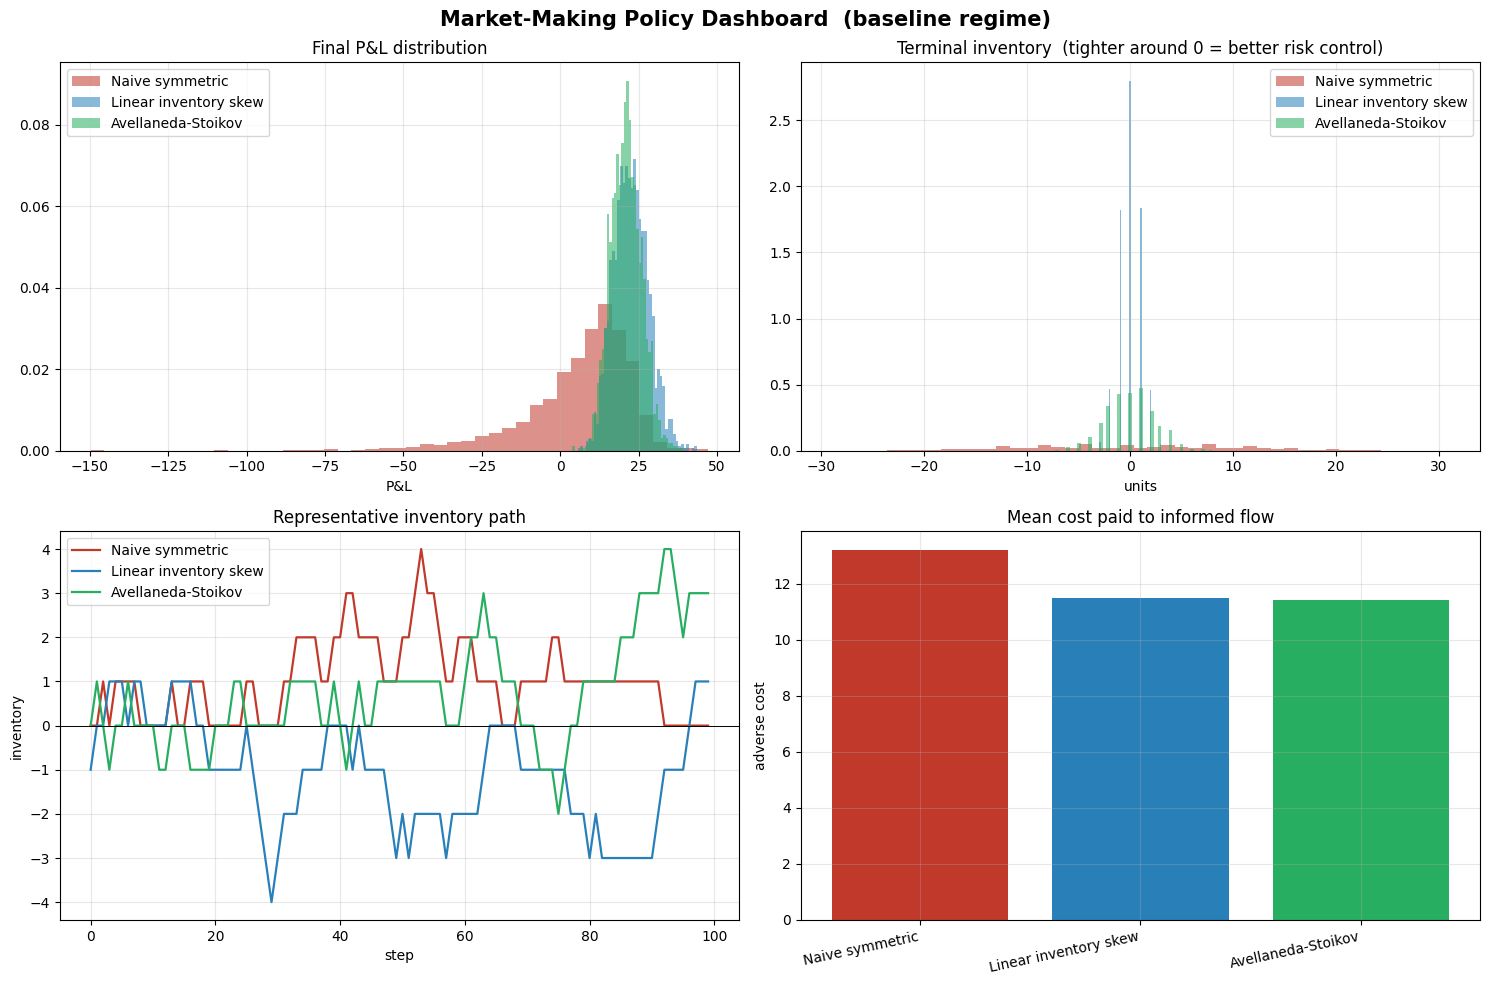

In [5]:
colors = {"Naive symmetric": "#c0392b",
          "Linear inventory skew": "#2980b9",
          "Avellaneda-Stoikov": "#27ae60"}

# one representative inventory path per policy, on a shared RNG for fairness
rng = np.random.default_rng(1)
paths = {name: simulate_episode(strat, cfg, rng, keep_path=True).inventory_path
         for name, strat in STRATEGIES.items()}

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Market-Making Policy Dashboard  (baseline regime)", fontsize=15, fontweight="bold")

for s in STRATEGIES:
    sub = df[df.strategy == s]
    ax[0, 0].hist(sub.pnl, bins=45, alpha=0.55, density=True, color=colors[s], label=s)
    ax[0, 1].hist(sub.terminal_inventory, bins=45, alpha=0.55, density=True, color=colors[s], label=s)
    ax[1, 0].plot(paths[s], color=colors[s], lw=1.6, label=s)

ax[0, 0].set_title("Final P&L distribution"); ax[0, 0].set_xlabel("P&L"); ax[0, 0].legend()
ax[0, 1].set_title("Terminal inventory  (tighter around 0 = better risk control)")
ax[0, 1].set_xlabel("units"); ax[0, 1].legend()
ax[1, 0].set_title("Representative inventory path"); ax[1, 0].axhline(0, color="k", lw=0.7)
ax[1, 0].set_xlabel("step"); ax[1, 0].set_ylabel("inventory"); ax[1, 0].legend()

adv = df.groupby("strategy").adverse_cost.mean().reindex(list(STRATEGIES))
ax[1, 1].bar(range(len(adv)), adv.values, color=[colors[s] for s in adv.index])
ax[1, 1].set_xticks(range(len(adv))); ax[1, 1].set_xticklabels(adv.index, rotation=12, ha="right")
ax[1, 1].set_title("Mean cost paid to informed flow"); ax[1, 1].set_ylabel("adverse cost")

plt.tight_layout(); plt.show()

**Reading the baseline.** The naive policy — no inventory awareness — bleeds
into a wide, fat-tailed P&L distribution and lets inventory wander far from zero;
its return-over-risk is terrible. Both skewing policies collapse the inventory
distribution toward zero and roughly quadruple risk-adjusted return. Between the
two, note the honest tension: in this calm-ish regime the **linear skew** actually
posts higher raw mean P&L and even tighter terminal inventory, while
**Avellaneda–Stoikov** wins on *risk-adjusted* return via its adaptive spread. Which
matters more depends on the environment — motivating Experiment 2.

## 5. Experiment 2 — regime sweep

Where does the extra machinery of Avellaneda–Stoikov actually pay off? We sweep two
axes that stress the two hardest risks: **volatility** (inventory risk) and **toxic
fraction** (adverse selection).

In [6]:
regimes = {
    "Calm / low toxicity":      dict(sigma=0.20, toxic_frac=0.05),
    "Calm / high toxicity":     dict(sigma=0.20, toxic_frac=0.30),
    "Volatile / low toxicity":  dict(sigma=0.55, toxic_frac=0.05),
    "Volatile / high toxicity": dict(sigma=0.55, toxic_frac=0.30),
}

frames = []
for rname, ov in regimes.items():
    d = run_stress_test(MarketConfig(**ov), n_episodes=1500, seed=11)
    g = (d.groupby("strategy")
           .agg(mean_pnl=("pnl", "mean"),
                ret_over_risk=("pnl", lambda x: x.mean() / (x.std(ddof=0) + 1e-12)),
                abs_inv=("terminal_inventory", lambda x: x.abs().mean()))
           .reset_index())
    g["regime"] = rname
    frames.append(g)

sweep = pd.concat(frames, ignore_index=True)
pivot_ror = sweep.pivot(index="regime", columns="strategy", values="ret_over_risk").round(2)
pivot_ror = pivot_ror.reindex(list(regimes)).reindex(columns=list(STRATEGIES))
print("Return-over-risk by regime:"); pivot_ror

Return-over-risk by regime:


strategy,Naive symmetric,Linear inventory skew,Avellaneda-Stoikov
regime,,,
Calm / low toxicity,2.33,5.17,5.20
Calm / high toxicity,0.21,3.47,3.82
Volatile / low toxicity,0.49,3.09,3.04
Volatile / high toxicity,-0.90,1.13,2.30


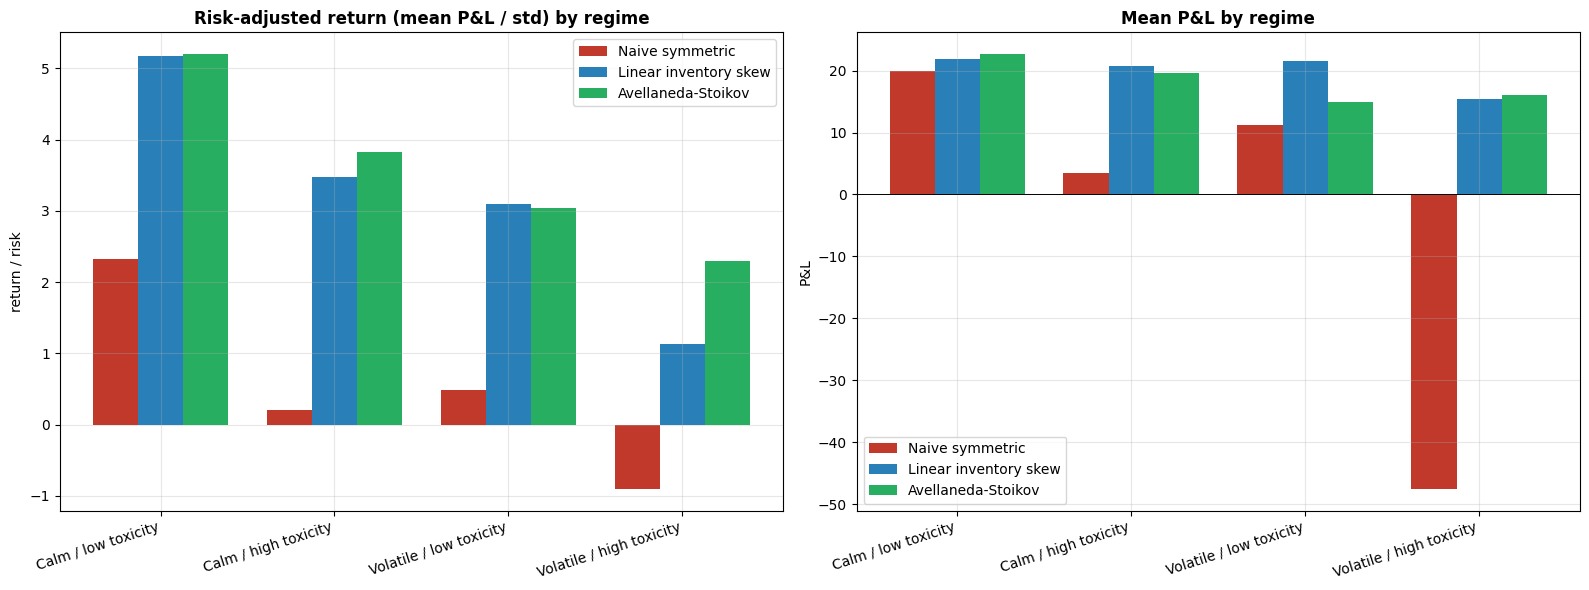

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# grouped bars: risk-adjusted return by regime
rlabels = list(regimes); x = np.arange(len(rlabels)); w = 0.26
for i, s in enumerate(STRATEGIES):
    ax[0].bar(x + (i - 1) * w, pivot_ror[s].values, w, color=colors[s], label=s)
ax[0].set_xticks(x); ax[0].set_xticklabels(rlabels, rotation=18, ha="right")
ax[0].set_title("Risk-adjusted return (mean P&L / std) by regime", fontweight="bold")
ax[0].set_ylabel("return / risk"); ax[0].legend()

# mean P&L by regime
pivot_pnl = (sweep.pivot(index="regime", columns="strategy", values="mean_pnl")
                  .reindex(rlabels).reindex(columns=list(STRATEGIES)))
for i, s in enumerate(STRATEGIES):
    ax[1].bar(x + (i - 1) * w, pivot_pnl[s].values, w, color=colors[s], label=s)
ax[1].axhline(0, color="k", lw=0.7)
ax[1].set_xticks(x); ax[1].set_xticklabels(rlabels, rotation=18, ha="right")
ax[1].set_title("Mean P&L by regime", fontweight="bold"); ax[1].set_ylabel("P&L"); ax[1].legend()

plt.tight_layout(); plt.show()

## 6. Findings

1. **Inventory control is the first-order survival factor.** The naive policy is
   fine in calm markets but detonates under stress — in the volatile / high-toxicity
   regime it runs a large directional position into a moving mid and posts a
   *negative* mean P&L. Any inventory skew removes most of that risk.

2. **Linear skew is a strong, cheap baseline** — competitive or better on raw P&L in
   calm regimes and consistently the tightest terminal inventory, because it skews at
   full strength regardless of the time horizon.

3. **Avellaneda–Stoikov earns its complexity specifically in hostile regimes.** In
   volatile / high-toxicity conditions its volatility- and time-aware spread widening
   gives it the best risk-adjusted return *and* the best raw P&L — it quotes wider
   exactly when the environment is most dangerous, which the fixed-spread policies
   can't do. In calm markets that caution is mildly costly.

The honest one-line takeaway: **skewing beats not-skewing by a mile; adaptivity beats
static skewing only when the market is genuinely dangerous.** That conditional result
is the point — a policy's value can't be judged outside the regime it faces.

## 7. Reproducibility, limitations, and where I'd take it next

**Reproducible.** Every experiment runs off a single seeded NumPy `Generator`; rerun
top-to-bottom for identical numbers. Logging here is intentionally lightweight
(in-memory `DataFrame`s) because we store *per-episode summaries* — a few thousand
rows. Only per-*round* logging across very many episodes would justify streaming to
Parquet/SQLite, and this study doesn't need it.

**Honest limitations.**
- Informed traders know the exact terminal $V$ — a deliberately strong form of
  adverse selection. Softening it to noisy/partial information would be more
  realistic and would narrow the gap to naive.
- The mid is an arithmetic random walk with constant $\sigma$; real microstructure
  has jumps, stochastic volatility, and mean reversion.
- One unit per fill, no queue position, no latency, no transaction costs.

**Natural extensions.** Order-flow-imbalance-driven spread widening (an EMA of recent
trade direction), stochastic volatility regimes, a learned quoting policy compared
against A–S as the analytic benchmark, and a fill model calibrated to real level-2
data. Each is a self-contained next experiment rather than a rewrite.